State to be teleported


<IPython.core.display.Latex object>

[0.70710678+0.j,0.70710678+0.j]


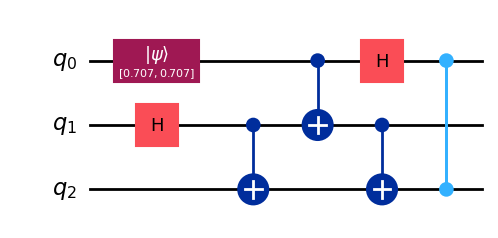

<IPython.core.display.Latex object>


Final State of Qubit 2 (Bob):


<IPython.core.display.Latex object>


Final density matrix of Qubit 2 (Bob):


<IPython.core.display.Latex object>

In [10]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from numpy import pi
from qiskit.quantum_info import *
from qiskit . visualization import plot_histogram
from numpy import sqrt
from IPython.display import Math, display
from qiskit.circuit.library import UnitaryGate
from numpy import pi, cos, sin, exp
from qiskit_aer import AerSimulator
from qiskit_aer.library import save_statevector

# State to be teleported

u = Statevector ([1 / sqrt(2) , 1 / sqrt(2) ])
print("State to be teleported")
display(u.draw("latex"))
print(u.draw("text"))

j = Statevector.from_label("0")
k = Statevector.from_label("0")

State_in = k.tensor(j).tensor(u)
# Building the 3 - qubit register and 2- Classical Register

q_reg = QuantumRegister(3,"q")

# Building the quantum circuit

circuit_1 = QuantumCircuit(q_reg)

# initializing the state that is to be transported

circuit_1.initialize(u,[0])

# creating a bell state between A and B

circuit_1.h(1)
circuit_1.cx(q_reg[1],q_reg[2])

# creating the main ckt

circuit_1.cx(q_reg[0],q_reg[1])
circuit_1.h(0)
circuit_1.cx(q_reg[1],q_reg[2])
circuit_1.cz(q_reg[0],q_reg[2])

display(circuit_1.draw(output='mpl'))

State_out = State_in.evolve(circuit_1)
display(State_out.draw("latex"))

bob_density_matrix = partial_trace(State_out, [0, 1])
bob_statevector = bob_density_matrix.to_statevector()

print("\nFinal State of Qubit 2 (Bob):")
display(bob_statevector.draw("latex"))

print("\nFinal density matrix of Qubit 2 (Bob):")
display(bob_density_matrix.draw("latex"))